# Smart Portfolio Lab : Data Pipeline & Setup

This notebook covers the initial data pipeline for the Smart Portfolio Lab project. You will see the downloading of adjusted price data for 10 US equities and the S&P500 index. We got all this data from Yahoo finance. Also, we will compute log returns and retrieve the risk-free rate from FRED.

**Universe:** AAPL, MSFT, AMZN, META, NFLX, TSLA, NVDA, JPM, BAC, XOM  
**Benchmark:** S&P 500 (^GSPC)  
**Period:** From January to 2013 Present  
**Frequency:** Daily and Monthly

## 1. Required Libraries

For this part, we use this librairies : 
- `yfinance` : to download historical price data from Yahoo Finance
- `pandas` : for data manipulation and time series handling
- `numpy` : for numerical computations
- `matplotlib` / `seaborn` : for static visualizations
- `plotly` : for interactive charts
- `statsmodels` : for statistical models and regressions
- `fredapi` : to have access to FRED macroeconomic data (risk-free rate)

In [2]:
# Libraries

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")

All libraries loaded successfully


## 2. Data download

We download adjusted closing prices for our 10 assets and the S&P500 benchmark. By using **Adjusted Close** prices where we able to account dividends and stock splits to ensure return calculations are economically accurate. 

- Considered Period : January 2013 to Today
- Frequence : Daily

In [9]:
# The Universe

TICKERS = ["AAPL", "MSFT", "AMZN", "META", "NFLX", 
           "TSLA", "NVDA", "JPM", "BAC", "XOM"]
BENCHMARK = "^GSPC" 
START_DATE = "2013-01-01"
END_DATE = None #today 

ALL_TICKERS = TICKERS + [BENCHMARK]

# Downloading
print(f"Downloading {len(ALL_TICKERS)} tickers from {START_DATE} to today...")
raw_data = yf.download(
    tickers = ALL_TICKERS,
    start = START_DATE, 
    end = END_DATE, 
    auto_adjust = True, #gives Ajusted Close directly
    progress = False
)

#Only the 'Close' column is kept  (= Adjusted Close after auto_adjust=True)
prices = raw_data["Close"].copy()

print(f"\nDownload complete.")
print(f" Shape  : {prices.shape[0]} trading days  x {prices.shape[1]} assets")
print(f" From   : {prices.index[0]. date ()}")
print(f" To     : {prices.index[-1]. date()}")
print(f"\nMissing Values per asset :")
print(prices.isna().sum())


Download complete.
 Shape  : 3318 trading days  x 11 assets
 From   : 2013-01-02
 To     : 2026-03-12

Missing Values per asset :
Ticker
AAPL     0
AMZN     0
BAC      0
JPM      0
META     0
MSFT     0
NFLX     0
NVDA     0
TSLA     0
XOM      0
^GSPC    0
dtype: int64


## 3. Processing - Log Returns

We Compute **daily log returns** from adjusted prices. Log-return formula: r_t = ln(P_t / P_{t-1})

Why log return over simple returns ? 
1. **Time additivity** : a 2-day log return = sum of two 1-day log returns
2. **Near stationarity** : log returns stabilize variance over time
4. **Model compatibility** : required by most quantitative models

We also compute **monthly log returns** by resampling. This will be useful for covariance estimation because they will be less noise than daily. 

In [36]:
#Daily log returns 
log_returns_daily = np.log(prices/prices.shift(1)).dropna()

#Monthly Log returns
log_returns_monthly = np.log(
    prices.resample("ME").last() / prices.resample("ME").last().shift(1)
).dropna()

#Separate assets from benchmark 

returns_daily = log_returns_daily[TICKERS]
returns_monthly = log_returns_monthly[TICKERS]

benchmark_daily = log_returns_daily[BENCHMARK]
benchmark_monthly = log_returns_monthly[BENCHMARK]

print("===Daily Log returns ===")
print(f"Shape     : {returns_daily.shape}")
print(f"Date range: {returns_daily.index[0].date()} → {returns_daily.index[-1].date()}")
print(f"\nNAN check:{returns_daily.isna().sum().sum()} total NaN values")
print(f"\nSample (last 3 rows) : \n{returns_daily.tail(3).round(4)}")

print("\n=== Monthly Log returns ===")
print(f"Shape      : {returns_monthly.shape}")
print(f"NaN check  : {returns_monthly.isna().sum().sum()} total NaN values")

===Daily Log returns ===
Shape     : (3317, 10)
Date range: 2013-01-03 → 2026-03-12

NAN check:0 total NaN values

Sample (last 3 rows) : 
Ticker        AAPL    MSFT    AMZN    META    NFLX    TSLA    NVDA     JPM  \
Date                                                                         
2026-03-10  0.0036 -0.0090  0.0039  0.0103 -0.0141  0.0014  0.0115 -0.0041   
2026-03-11 -0.0001 -0.0022 -0.0079  0.0012 -0.0214  0.0213  0.0069 -0.0042   
2026-03-12 -0.0196 -0.0075 -0.0148 -0.0258 -0.0061 -0.0319 -0.0157 -0.0162   

Ticker         BAC     XOM  
Date                        
2026-03-10  0.0137 -0.0155  
2026-03-11 -0.0008  0.0230  
2026-03-12 -0.0291  0.0128  

=== Monthly Log returns ===
Shape      : (158, 10)
NaN check  : 0 total NaN values


## 4. Risk-Free Rate : FRED API (DGS1)

We retrieve the **1 Year US Treasury yield** (DGS1) from the Federal Reserve Economic Database as our risk-free rate proxy.

- **Series** : DGS1 1 year Treasury Constant Maturity Rate
- **Unit**   : annualized percentage (we convert to daily and monthly decimal)
- **Why DGS1** : startd proxy for short-term risk-free rate in equity portofolio analysis

In [16]:
#Risk-free rate from FRED
from fredapi import Fred

FRED_API_KEY = "d7366767a5286d6810cab1595be022bb"
fred = Fred(api_key=FRED_API_KEY)

#Downloading of DGS1 (annualized %, business days)
rf_raw = fred.get_series("DGS1", observation_start=START_DATE)
rf_raw = rf_raw.dropna()

#Converting : annualized % to daily decimal 
#DGS1 is in % per year
#Daily rate = annual rate / 252 trdaing days / 100
rf_daily = rf_raw / 100 / 252

#To align with our return index
rf_daily = rf_daily.reindex(returns_daily.index, method="ffill")

#Monthly risk-free rate 
rf_monthly = rf_daily.resample("ME").sum()


print("=== Risk-Free Rate (DGS1) ===")
print(f"Shape       : {rf_daily.shape}")
print(f"Data range  : {rf_daily.index[0].date()} → {rf_daily.index[-1].date()}")
print(f"\nCurrent annualized RF : {rf_raw.iloc[-1]:.2f}%")
print(f"Current daily RF        : {rf_daily.iloc[-1]*100:.5f}%")
print(f"\nSample:\n{rf_daily.tail(5).round(6)}")


=== Risk-Free Rate (DGS1) ===
Shape       : (3317,)
Data range  : 2013-01-03 → 2026-03-12

Current annualized RF : 3.66%
Current daily RF        : 0.01452%

Sample:
Date
2026-03-06    0.000141
2026-03-09    0.000141
2026-03-10    0.000141
2026-03-11    0.000143
2026-03-12    0.000145
dtype: float64


## 5. Descriptive Statistics

We compute the **four statistical moments** of daily log returns for each asset, plus the correlation matrix.

Key metrics : 
- **Annualized Mean Return**: daily mean x 252
- **Annualized Volatility**: daily std x square root of 252
- **Skewness**: negative = more extreme losses than gains (left tail risk)
- **Kurtosis**: excess kurtosis >  0 = fat tails (more extreme events than normal)
- **Sharpe Ratio** (raw): mean / std, preliminary ranking before risk-free adjustment.

In [22]:
#Descriptive Statistics

#Annualization constants
TRADING_DAYS = 252

#Computing of the 4 momments
stats = pd.DataFrame(index=TICKERS)

stats["Mean Return (ann.)"] = returns_daily.mean() * TRADING_DAYS
stats["Volatility  (ann.)"] = returns_daily.std() * np.sqrt(TRADING_DAYS)
stats["Skewness"]           = returns_daily.skew()
stats["Excess Kurtosis"]    = returns_daily.kurt()
stats["Min Daily Return"]   = returns_daily.min()
stats["Max Daily Return"]   = returns_daily.max()

#Raw Sharpe (no risk-free deduction yet, just mean and vol ratio)
stats["Raw Sharpe"]         = stats["Mean Return (ann.)"] / stats["Volatility  (ann.)"]

#Format for display
stats_display = stats.copy()
stats_display["Mean Return (ann.)"] = stats_display["Mean Return (ann.)"].map("{:.2%}".format)
stats_display["Volatility  (ann.)"] = stats_display["Volatility  (ann.)"].map("{:.2%}".format)
stats_display["Skewness"]           = stats_display["Skewness"].round(3)
stats_display["Excess Kurtosis"]    = stats_display["Excess Kurtosis"].round(3)
stats_display["Min Daily Return"]   = stats_display["Min Daily Return"].map("{:.2%}".format)
stats_display["Max Daily Return"]   = stats_display["Max Daily Return"].map("{:.2%}".format)
stats_display["Raw Sharpe"]         = stats_display["Raw Sharpe"].round(3)


print("=== Descriptive Statistics: Daily Log returns ===\n")
print(stats_display.to_string())

#Normality test of Jarque-Bera
from scipy import stats as scipy_stats

print("\n=== Jarque-Bera Normality Test ===")
print(f"{'Asset':<8} {'JB Statistic' :>14} {'p-vaulue':>12} {'Normal?':>10}")
print("-" * 48)

for ticker in TICKERS : 
    jb_stat, p_val = scipy_stats. jarque_bera(returns_daily[ticker].dropna())
    is_normal = "Yes" if p_val > 0.05 else "No"
    print(f"{ticker:<8} {jb_stat:>14} {p_val:>12} {is_normal:>10}")

#Correlation matrix 
corr_matrix = returns_daily.corr()

print("\n=== Correlation Matrix ===\n")
print(corr_matrix.round(2).to_string())

=== Descriptive Statistics: Daily Log returns ===

     Mean Return (ann.) Volatility  (ann.)  Skewness  Excess Kurtosis Min Daily Return Max Daily Return  Raw Sharpe
AAPL             20.78%             28.29%    -0.216            6.900          -13.77%           14.26%       0.735
MSFT             22.00%             26.36%    -0.254            8.804          -15.95%           13.29%       0.835
AMZN             21.20%             32.37%     0.010            5.998          -15.14%           13.22%       0.655
META             23.80%             38.14%    -0.493           25.169          -30.64%           25.94%       0.624
NFLX             32.46%             44.73%    -0.329           31.078          -43.26%           35.22%       0.726
TSLA             38.91%             57.38%     0.055            4.614          -23.65%           21.83%       0.678
NVDA             48.90%             45.29%     0.164            7.869          -20.77%           26.09%       1.080
JPM              16.6

## 6. Visualizations

1. **Normalizes Price evolution** : rebased to 100 at inception, shows relative trajectories
2. **Return Distributions** : overlaid with Normal fit to visualize fat tails
3. **Risk Return Scatter** : annualized vol vs mean return, the core of Markowitz intuition
4. **Correlation Heatmap** : visual representation of diversification potential

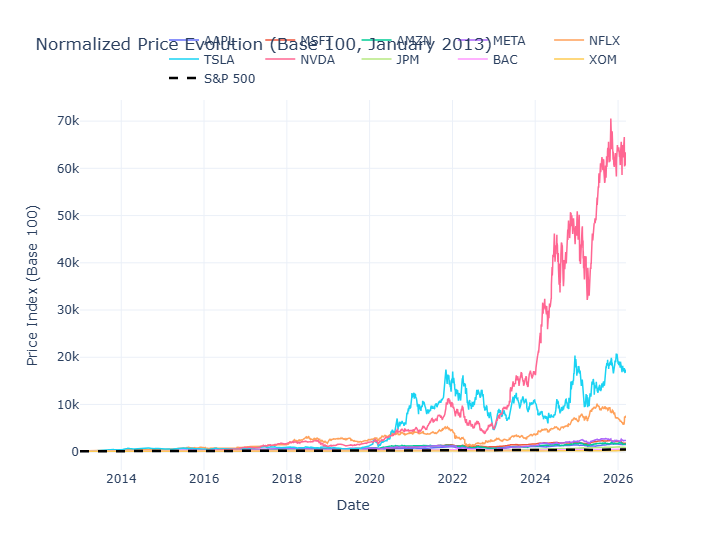

Figure saved: 01_normalized_prices


In [30]:
#1.Normalized Price evolution
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#Rebasing all prices to 100 at start date 
prices_norm = prices[TICKERS] / prices[TICKERS].iloc[0] * 100

fig1 = go.Figure()

for ticker in TICKERS: 
    fig1.add_trace(go.Scatter(
        x   = prices_norm.index,
        y   = prices_norm[ticker],
        name = ticker,
        mode = "lines",
        line = dict(width=1.5)
    ))

#Adding S&P500 as thick dashed benchmark
sp500_norm = prices[BENCHMARK] / prices[BENCHMARK].iloc[0] * 100
fig1.add_trace(go.Scatter(
    x      = sp500_norm.index,
    y      = sp500_norm,
    name   = "S&P 500",
    mode   = "lines",
    line   = dict(color="black", width=2.5, dash="dash")
))

fig1.update_layout(
    title       = "Normalized Price Evolution (Base 100, January 2013)",
    xaxis_title = "Date",
    yaxis_title = "Price Index (Base 100)",
    template    = "plotly_white",
    height      = 550,
    legend      =dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig1.show()
fig1.write_html("01_normalized_prices.html")
print("Figure saved: 01_normalized_prices")

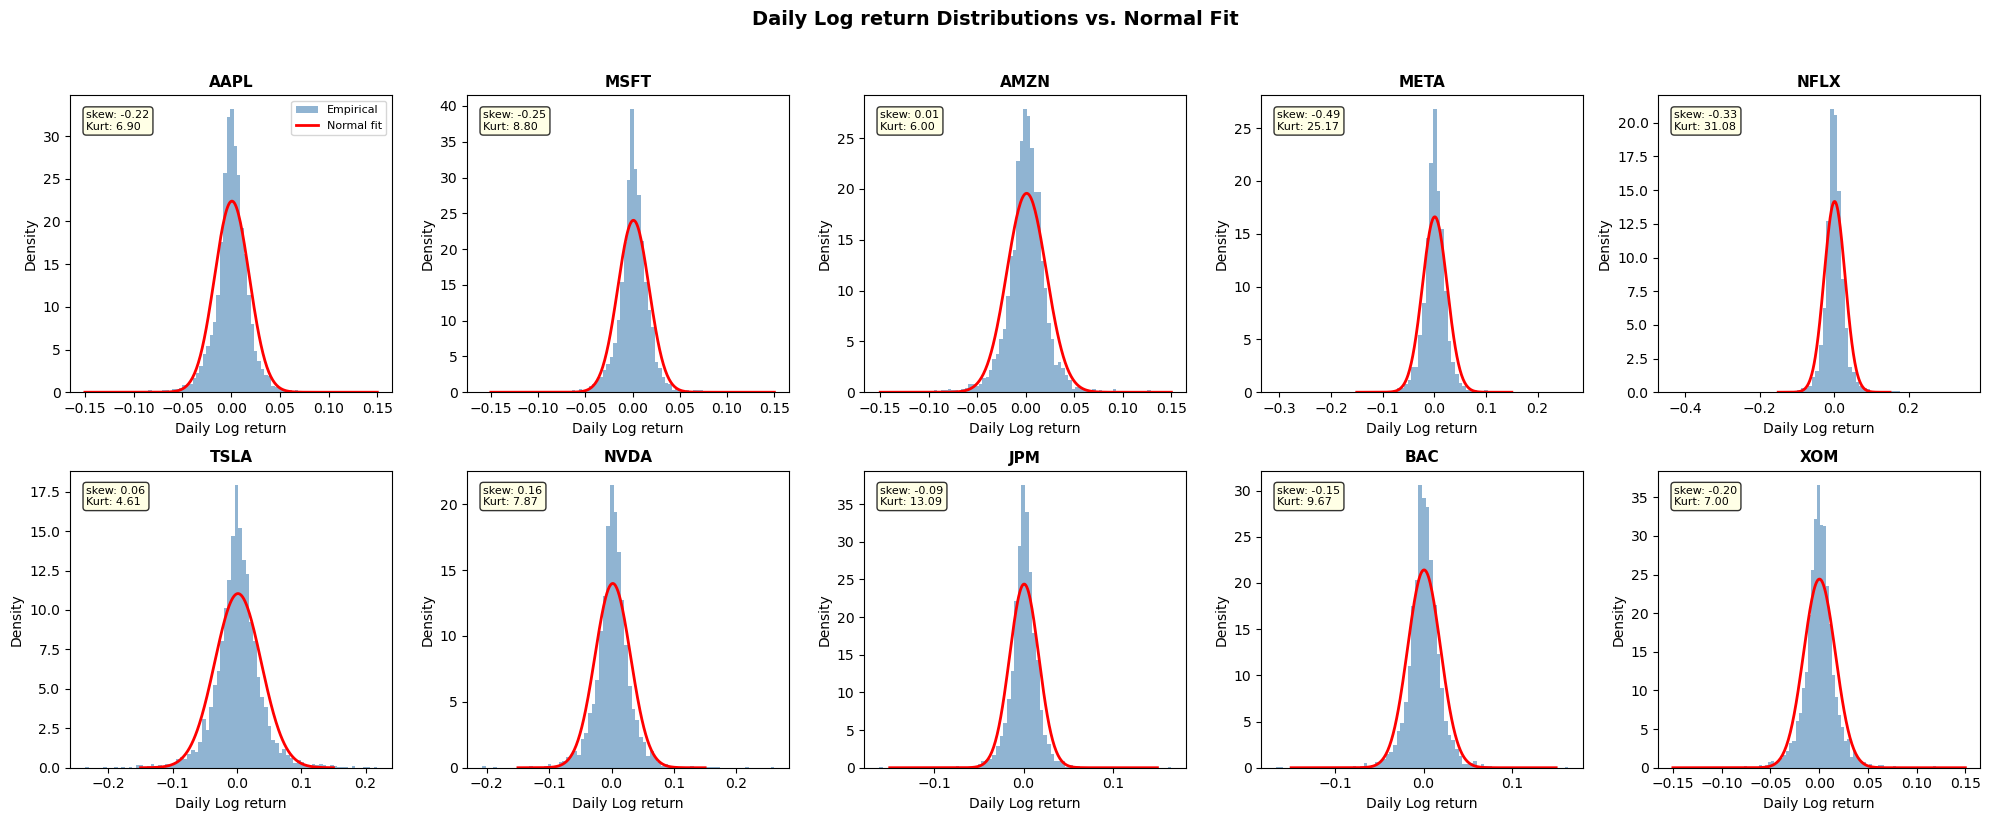

Figure saved : 02_return_distributions


In [31]:
#2. Return Distributions vs Normal Fit
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm

fig2, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

x_range = np.linspace(-0.15, 0.15, 300)

for i, ticker in enumerate(TICKERS):
    ax = axes[i]
    ret = returns_daily[ticker].dropna()

    #Empirical distribution (histogram)
    ax.hist(ret, bins=80, density=True, color="steelblue", alpha=0.6, label="Empirical")

    #Normal fit overlay
    mu_fit, std_fit = norm.fit(ret)
    ax.plot(x_range, norm.pdf(x_range, mu_fit, std_fit), color="red", linewidth=2, label="Normal fit")

    #Annotations
    ax.set_title(f"{ticker}", fontweight="bold", fontsize=11)
    ax.set_xlabel("Daily Log return")
    ax.set_ylabel("Density")

    skew_val = ret.skew()
    kurt_val = ret.kurt()
    ax.text(0.05, 0.95, f"skew: {skew_val:.2f}\nKurt: {kurt_val:.2f}",
            transform=ax.transAxes, fontsize=8,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle("Daily Log return Distributions vs. Normal Fit",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("Figure saved : 02_return_distributions", dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved : 02_return_distributions")

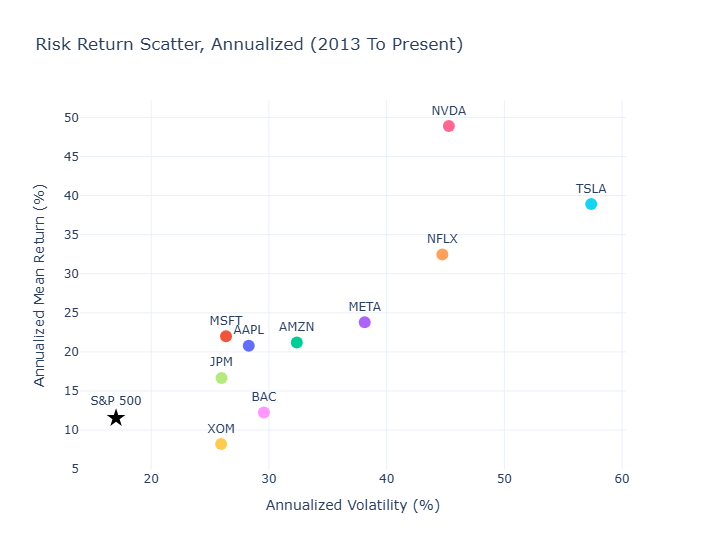

Figures saved : 03_risk_return_scatter


In [40]:
#3. Risk return Scatter Plot

ann_mean = returns_daily[TICKERS].mean() * TRADING_DAYS * 100 # in %
ann_vol  = returns_daily[TICKERS].std() * np.sqrt(TRADING_DAYS) * 100

bm_mean  = benchmark_daily.mean() * TRADING_DAYS * 100
bm_vol   = benchmark_daily.std()  * np.sqrt(TRADING_DAYS) * 100

fig3 = go.Figure()

#Plot of each asset
for ticker in TICKERS: 
    fig3.add_trace(go.Scatter(
        x    =[ann_vol[ticker]],
        y    =[ann_mean[ticker]],
        mode = "markers+text",
        name = ticker,
        text = [ticker],
        textposition = "top center",
        marker = dict(size=12)
    ))

#Benchmark Plot
fig3.add_trace(go.Scatter(
    x    =[bm_vol],
    y    =[bm_mean],
    mode = "markers+text",
    name = "S&P 500",
    text = ["S&P 500"],
    textposition = "top center",
    marker = dict(size=14, symbol="star", color="black")
))

fig3.update_layout(
    title       = "Risk Return Scatter, Annualized (2013 To Present)",
    xaxis_title = "Annualized Volatility (%)",
    yaxis_title = "Annualized Mean Return (%)",
    template    = "plotly_white",
    height      = 550,
    showlegend = False
)

fig3.show()
fig3.write_html("Figures saved : 03_risk_return_scatter")
print("Figures saved : 03_risk_return_scatter")

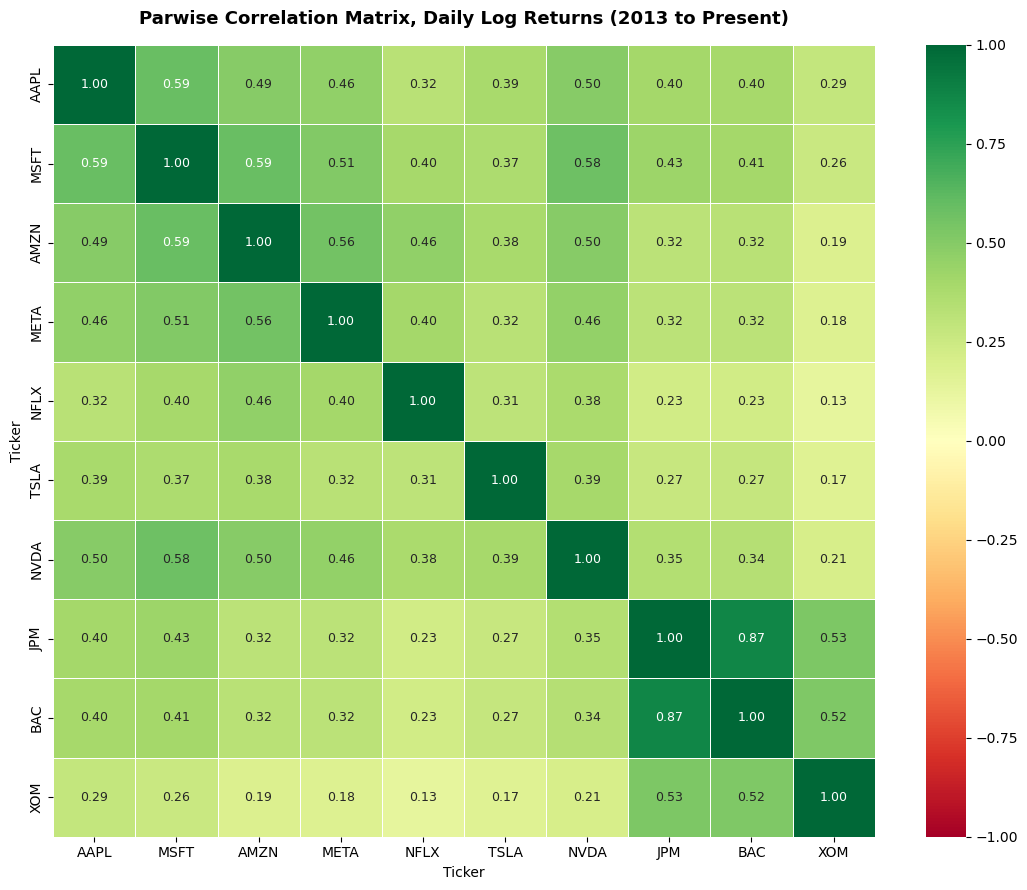

Figure saved : 04_correlation_heatmap


In [42]:
#4. Correlation Heatmap

import seaborn as sns
fig4, ax = plt.subplots(figsize=(11,9))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  #upper triangle mask

sns.heatmap(
    corr_matrix,
    annot      = True,
    fmt        = ".2f",
    cmap       = "RdYlGn",
    center     = 0,
    vmin       = -1,
    vmax       = 1,
    linewidths = 0.5,
    ax         = ax,
    annot_kws  = {"size": 9}
)

ax.set_title("Parwise Correlation Matrix, Daily Log Returns (2013 to Present)",
             fontsize=13, fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig("Figure saved : 04_correlation_heatmap")
plt.show()
print("Figure saved : 04_correlation_heatmap")